# Dataset EDA for Satellite Trail Segmentation

This notebook explores the processed subset and the supporting metadata catalogue. It uses reusable functions from `src/evaluation/eda.py` and `src/data/catalog.py`, and saves all figures to `results/figures/`.

In [1]:
import sys
sys.path.append("..")
from pathlib import Path

import pandas as pd
from IPython.display import display

from src.data.catalog import SatelliteCatalog
from src.evaluation.eda import (
    compute_image_summary_dataframe,
    compute_patch_dataframe,
    plot_example_satellite_trail_patches,
    plot_image_level_summary,
    plot_metadata_missing_values,
    plot_patch_density_distribution,
    plot_patch_density_heatmap,
    plot_ra_dec_distributions,
    plot_ra_dec_ranges,
    plot_random_image_mask_pairs,
    plot_random_mask_overlays,
    plot_satellite_name_frequency,
    plot_trail_length_distribution,
    summarise_patch_dataframe,
    summarise_patches_by_image,
)
from src.utils.logger import get_logger

In [2]:
processed_dir = Path("../data/subset/processed")
catalog_path = Path("../data/subset/metadata/Satellites_Catalog_Application.csv")
figure_dir = Path("results/figures")
patch_size = 512
stride = 512
logger = get_logger("dataset_eda")

figure_dir.mkdir(parents=True, exist_ok=True)
processed_dir, catalog_path, figure_dir

(PosixPath('../data/subset/processed'),
 PosixPath('../data/subset/metadata/Satellites_Catalog_Application.csv'),
 PosixPath('results/figures'))

## Dataset overview

Build the reusable summaries once, then reuse them throughout the notebook.

In [3]:
catalog = SatelliteCatalog(catalog_path)
image_df = compute_image_summary_dataframe(processed_dir)
patch_df = compute_patch_dataframe(
    root_dir=processed_dir,
    patch_size=patch_size,
    stride=stride,
    logger=logger,
)
patch_summary_df = summarise_patches_by_image(patch_df)
dataset_stats = summarise_patch_dataframe(patch_df)

dataset_summary_df = pd.DataFrame([dataset_stats.to_dict()])
dataset_summary_df["empty_patch_fraction"] = (
    dataset_summary_df["empty_patches"] / dataset_summary_df["total_patches"]
)
dataset_summary_df["non_empty_patch_fraction"] = (
    dataset_summary_df["non_empty_patches"] / dataset_summary_df["total_patches"]
)

display(dataset_summary_df)
display(image_df)
display(patch_summary_df)
display(
    patch_df.loc[:, ["image_name", "y", "x", "positive_pixel_fraction", "is_empty"]]
    .sort_values("positive_pixel_fraction", ascending=False)
    .head(10)
)

,total_images,total_patches,empty_patches,non_empty_patches,positive_pixel_fraction,empty_patch_fraction,non_empty_patch_fraction
0,21,8400,7880,520,0.000714,0.938095,0.061905


,image_name,width,height,image_mean,image_std,mask_positive_pixels,mask_positive_fraction
0,ML1_20170902_022840_red.fits_full.png,10560,10560,87.473401,31.704164,40764,0.000366
1,ML1_20171023_002210_red.fits_full.png,10560,10560,90.532847,29.477240,48685,0.000437
2,ML1_20171023_003240_red.fits_full.png,10560,10560,114.215970,27.521537,74296,0.000666
3,ML1_20171023_014550_red.fits_full.png,10560,10560,89.188906,29.955967,32509,0.000292
4,ML1_20181227_184754_red.fits_full.png,10560,10560,87.594588,32.370890,59008,0.000529
5,ML1_20181231_193445_red.fits_full.png,10560,10560,96.521772,29.353874,92664,0.000831
6,ML1_20181231_194444_red.fits_full.png,10560,10560,87.416639,30.986711,71071,0.000637
7,ML1_20190108_192313_red.fits_full.png,10560,10560,111.075176,28.000502,125940,0.001129
8,ML1_20190121_194039_red.fits_full.png,10560,10560,86.260527,29.967570,70255,0.000630
9,ML1_20190123_223503_red.fits_full.png,10560,10560,82.075666,33.209975,145629,0.001306


,image_name,total_patches,empty_patches,mean_positive_fraction,max_positive_fraction,non_empty_patches
0,ML1_20170902_022840_red.fits_full.png,400,378,0.000389,0.009243,22
1,ML1_20171023_002210_red.fits_full.png,400,379,0.000437,0.020351,21
2,ML1_20171023_003240_red.fits_full.png,400,377,0.000691,0.015434,23
3,ML1_20171023_014550_red.fits_full.png,400,378,0.000301,0.006504,22
4,ML1_20181227_184754_red.fits_full.png,400,376,0.000547,0.015690,24
5,ML1_20181231_193445_red.fits_full.png,400,373,0.000846,0.026157,27
6,ML1_20181231_194444_red.fits_full.png,400,388,0.000642,0.027054,12
7,ML1_20190108_192313_red.fits_full.png,400,362,0.001143,0.032890,38
8,ML1_20190121_194039_red.fits_full.png,400,369,0.000655,0.015789,31
9,ML1_20190123_223503_red.fits_full.png,400,377,0.001247,0.035641,23


,image_name,y,x,positive_pixel_fraction,is_empty
3817,ML1_20190123_223503_red.fits_full.png,5120,8704,0.035641,False
7553,ML1_20190822_034309_red.fits_full.png,8704,6656,0.034866,False
3973,ML1_20190123_223503_red.fits_full.png,9216,6656,0.034195,False
7535,ML1_20190822_034309_red.fits_full.png,8192,7680,0.033970,False
3758,ML1_20190123_223503_red.fits_full.png,3584,9216,0.033489,False
3797,ML1_20190123_223503_red.fits_full.png,4608,8704,0.033436,False
7588,ML1_20190822_034309_red.fits_full.png,9728,4096,0.033424,False
7517,ML1_20190822_034309_red.fits_full.png,7680,8704,0.033298,False
7571,ML1_20190822_034309_red.fits_full.png,9216,5632,0.033260,False
3179,ML1_20190108_192313_red.fits_full.png,9216,9728,0.032890,False


## Full-frame image and mask inspection

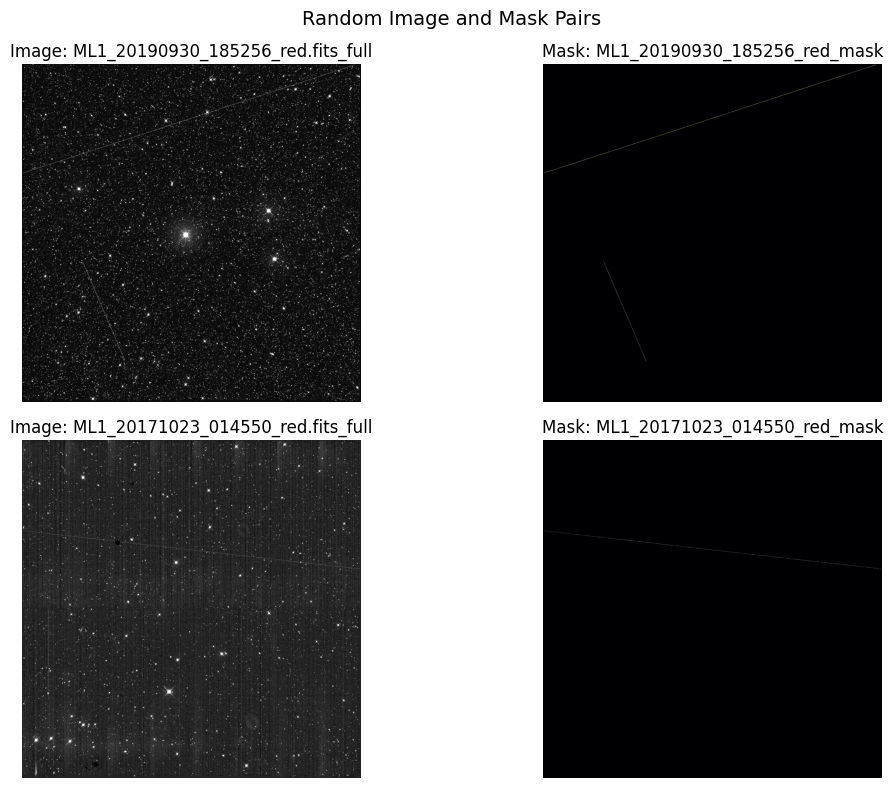

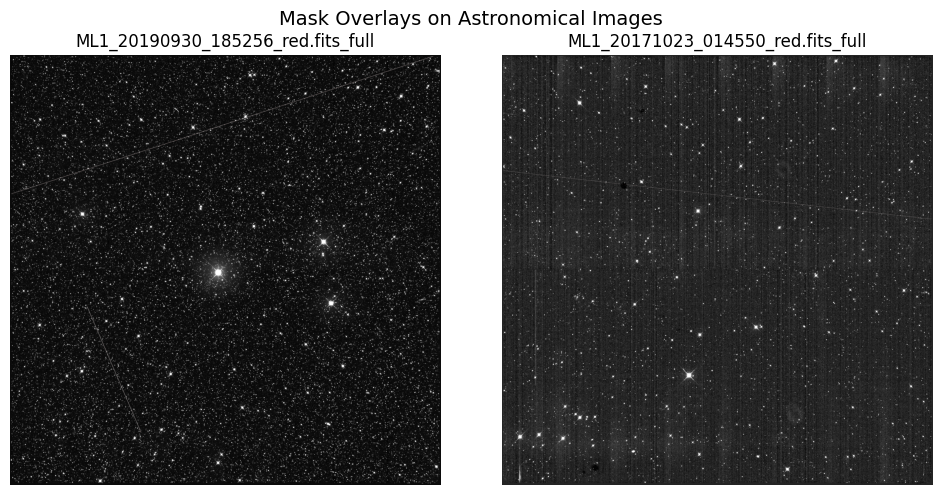

{'random_pairs': PosixPath('results/figures/eda_random_image_mask_pairs.png'),
 'overlays': PosixPath('results/figures/eda_random_mask_overlays.png')}

In [4]:
figure_paths = {}
figure_paths["random_pairs"] = plot_random_image_mask_pairs(
    root_dir=processed_dir,
    sample_count=2,
    seed=42,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["overlays"] = plot_random_mask_overlays(
    root_dir=processed_dir,
    sample_count=2,
    seed=42,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths

## Patch-level structure, sparsity, and trail examples

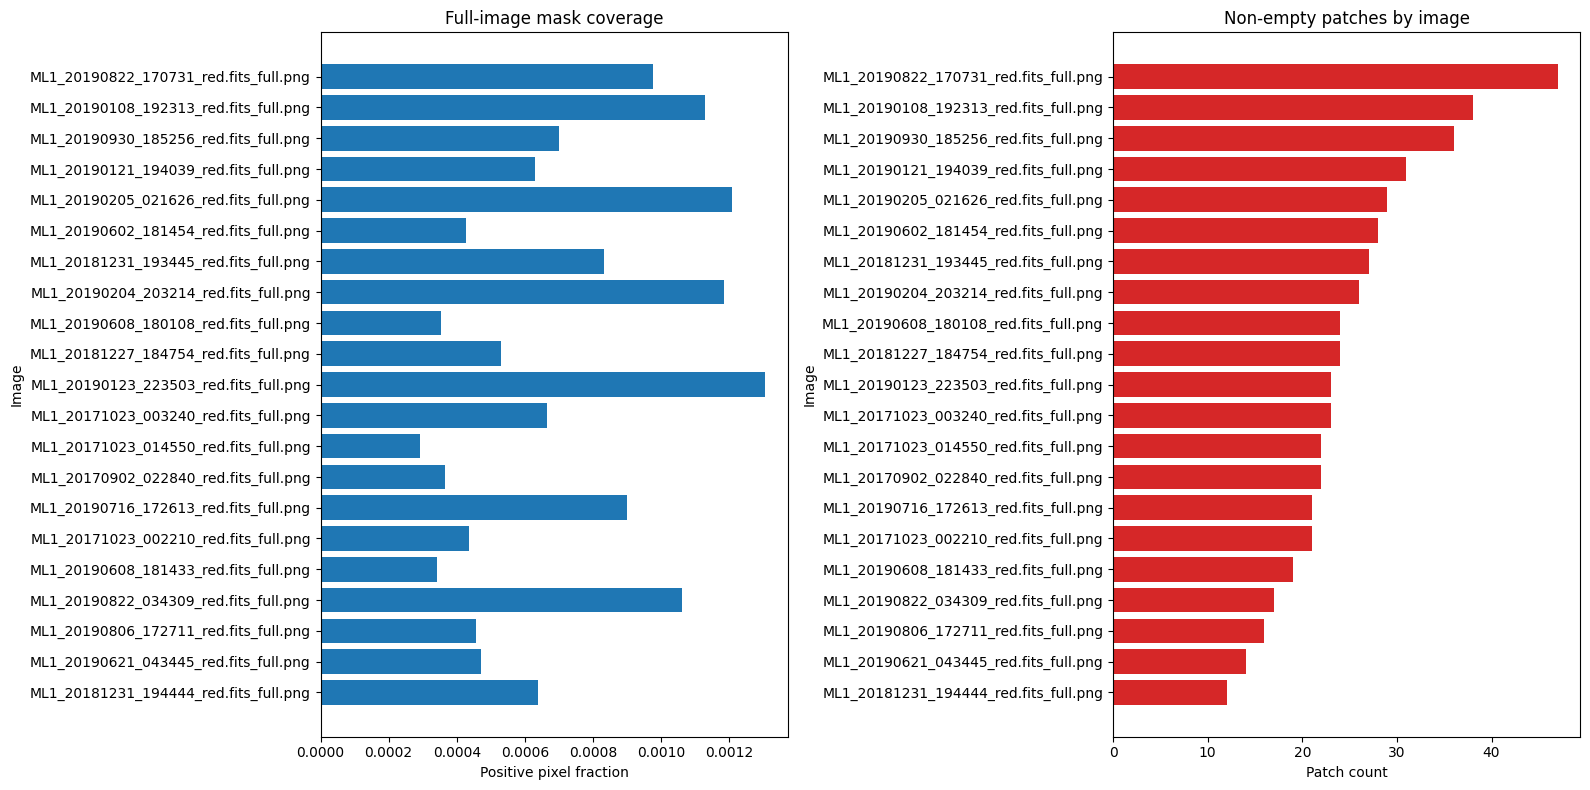

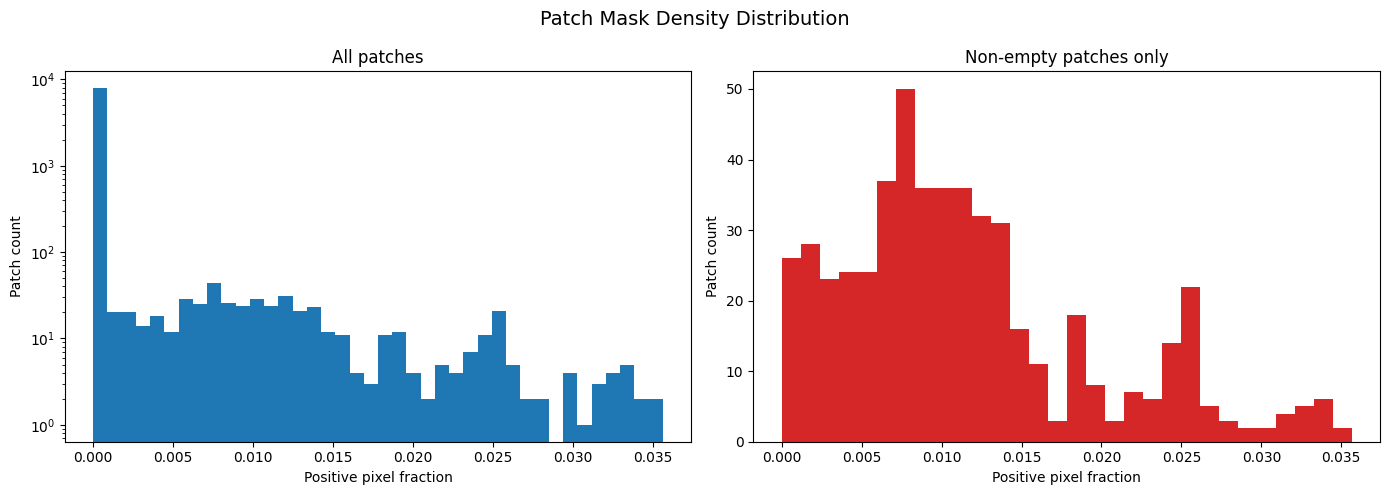

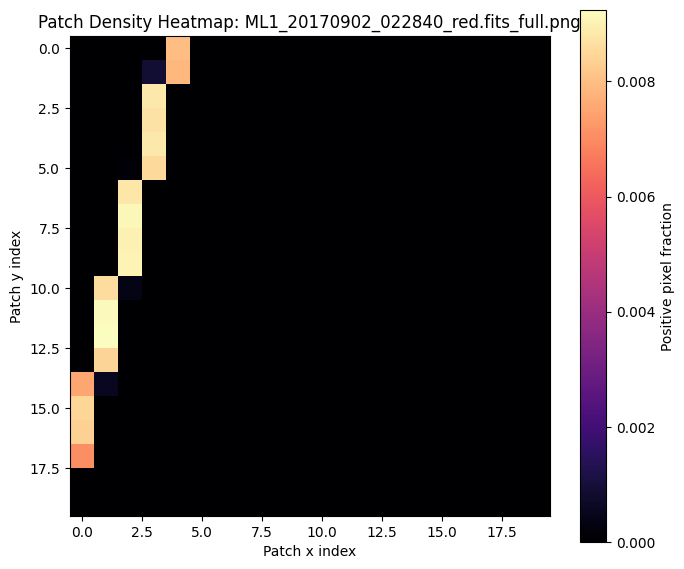

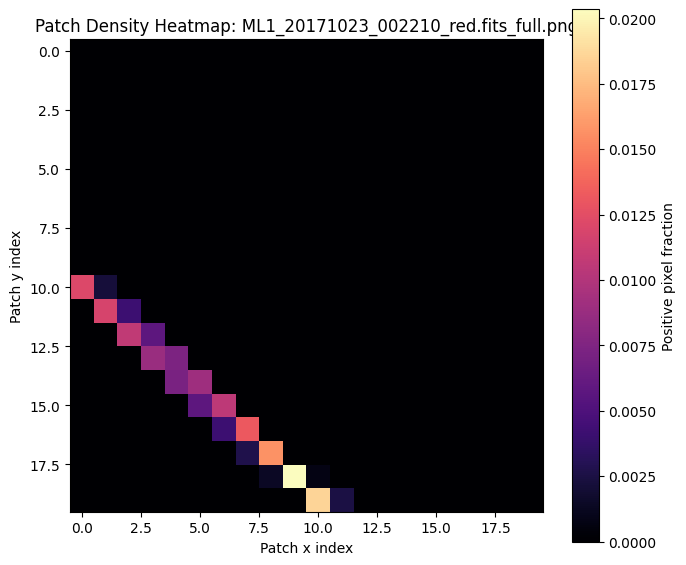

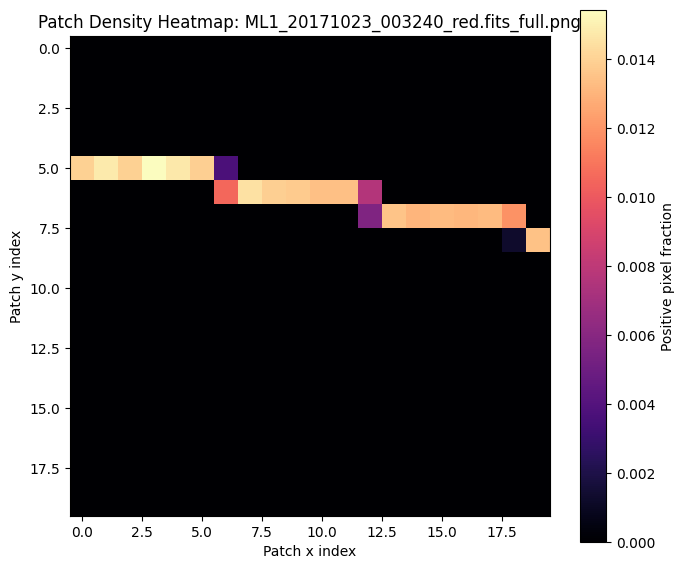

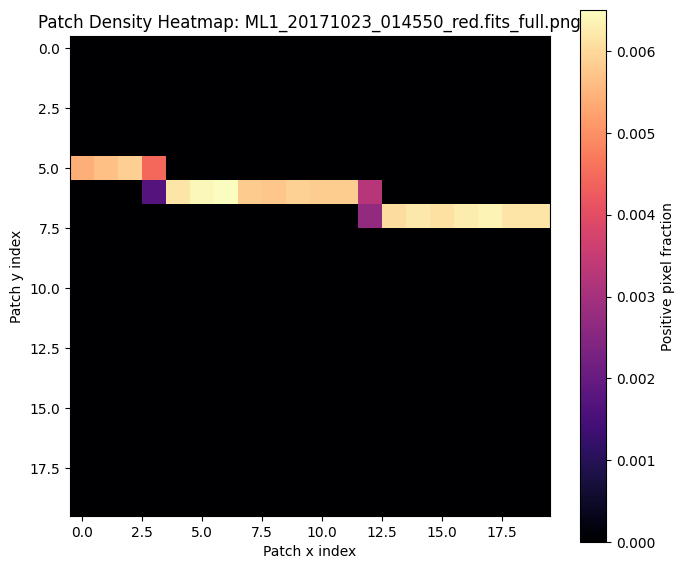

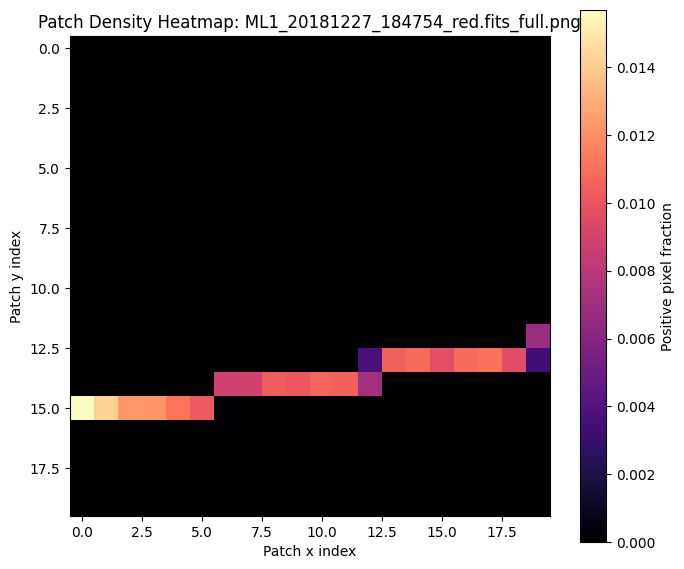

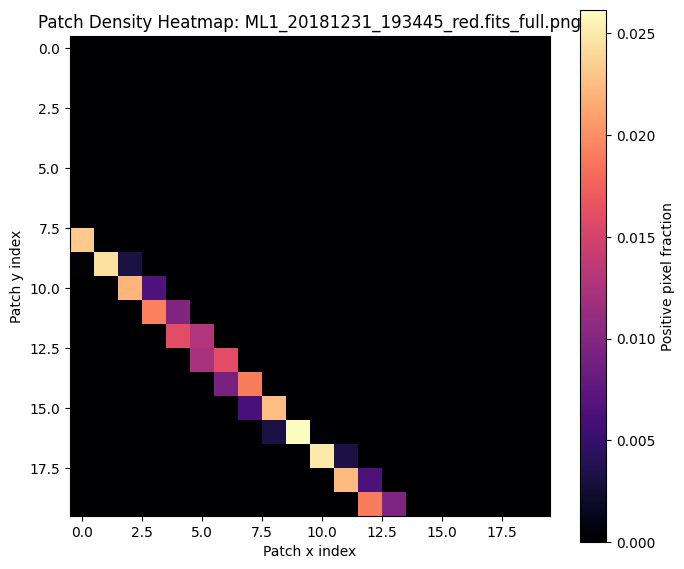

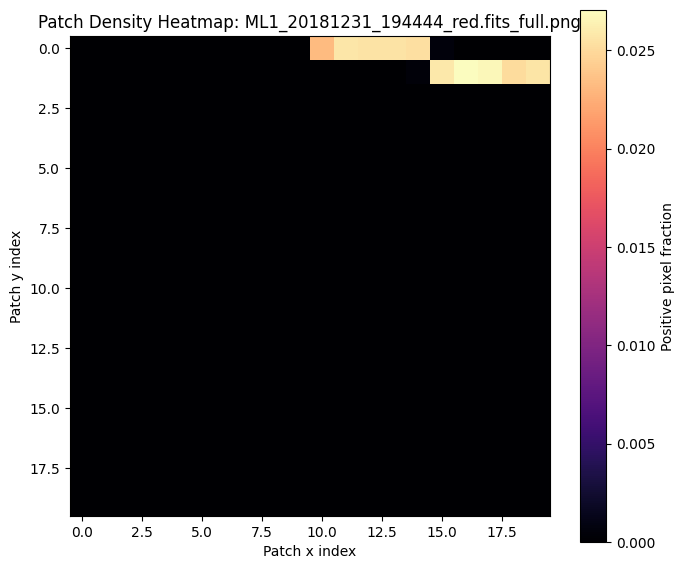

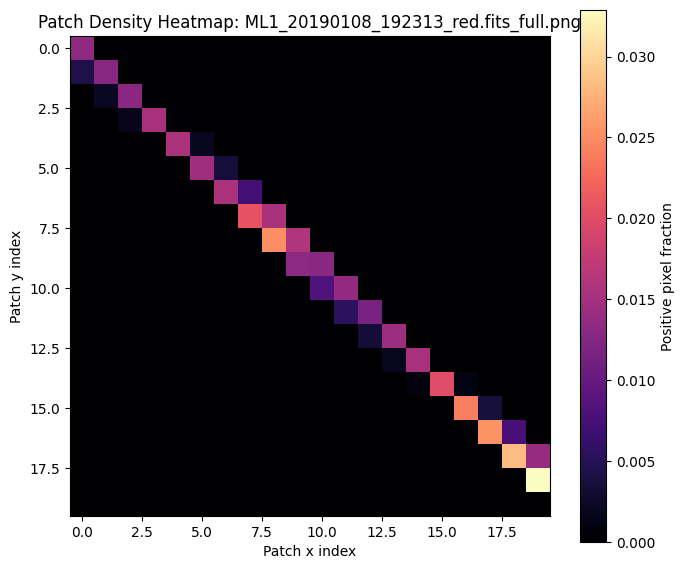

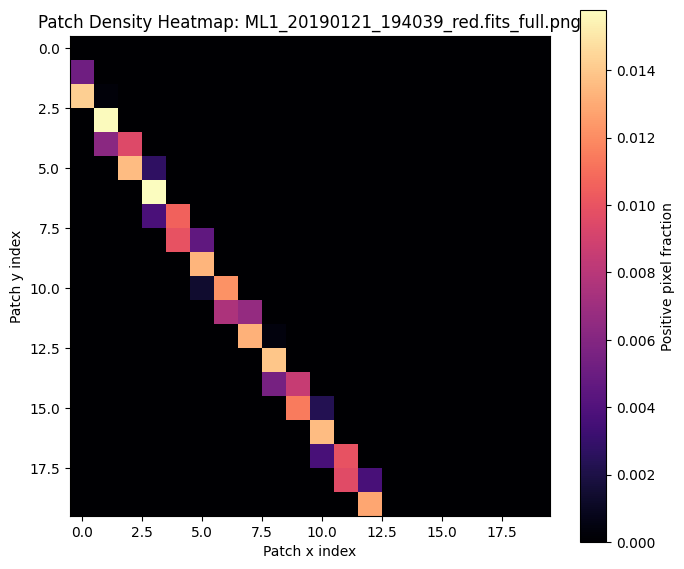

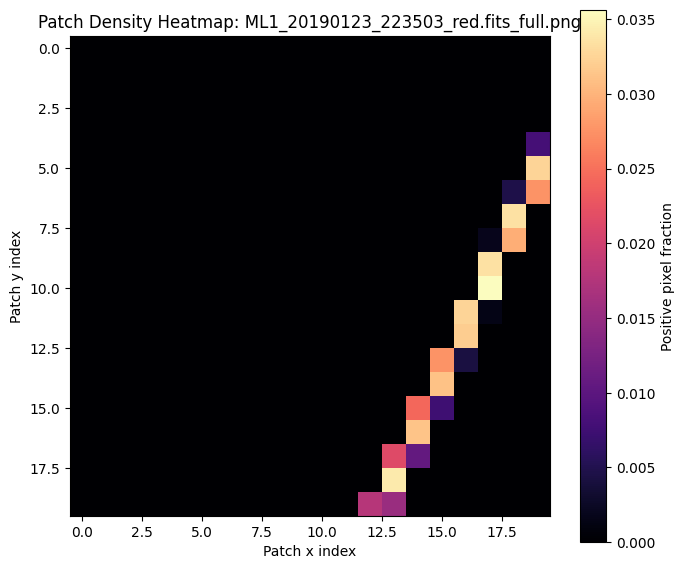

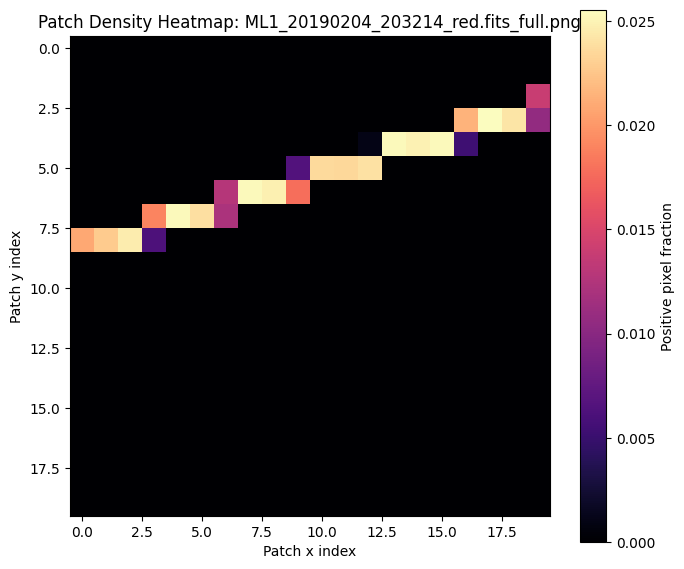

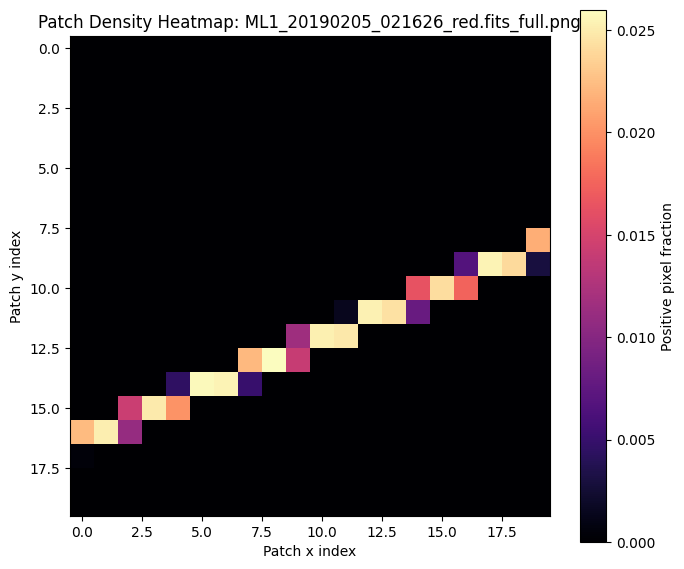

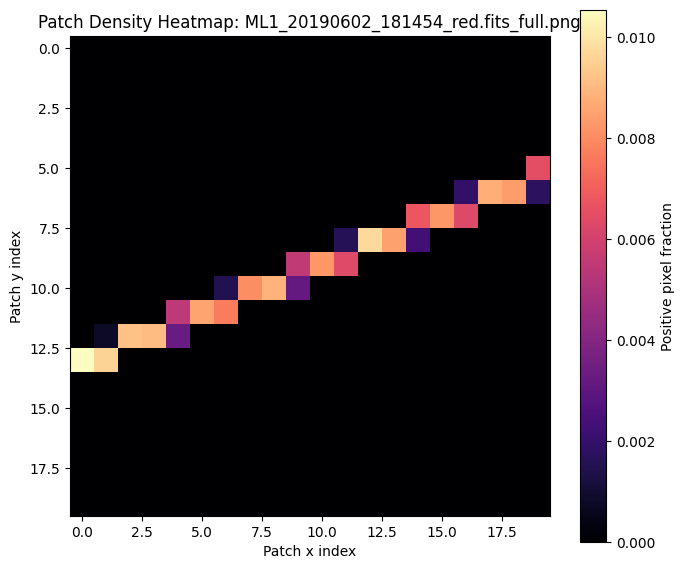

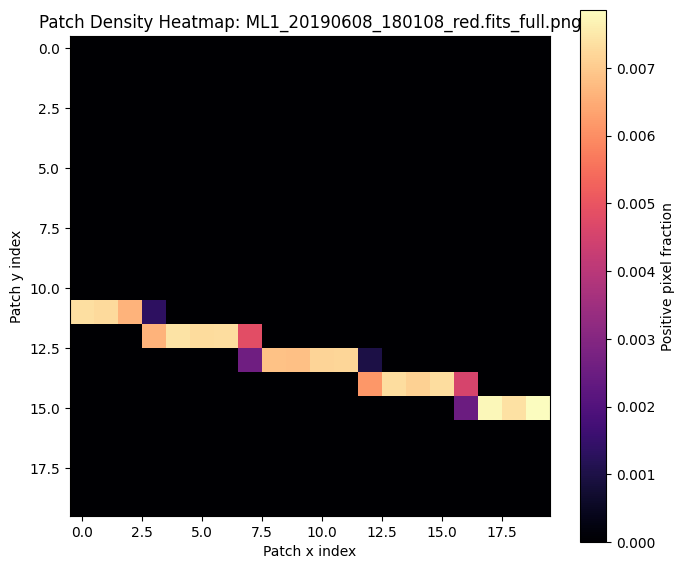

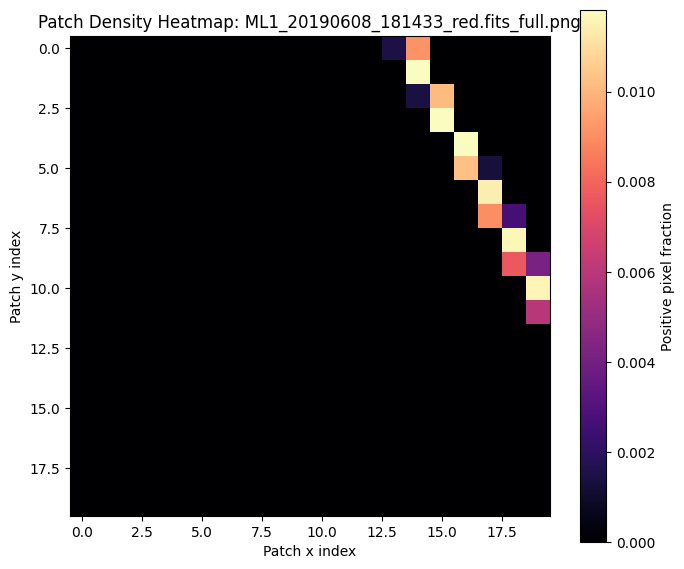

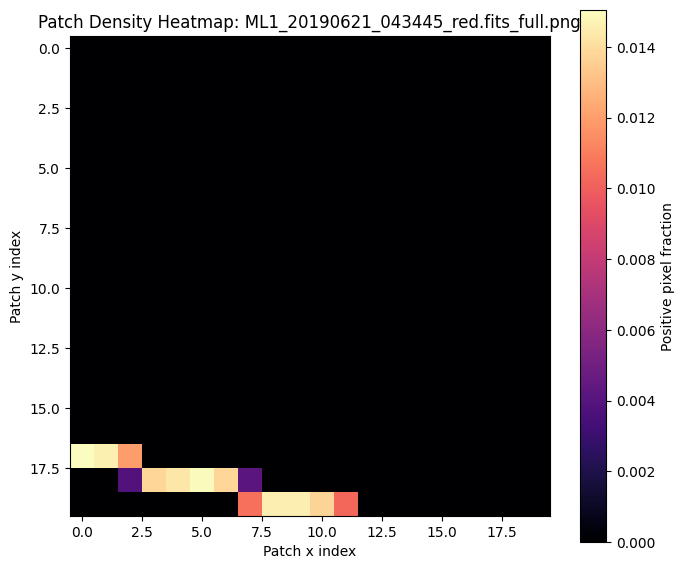

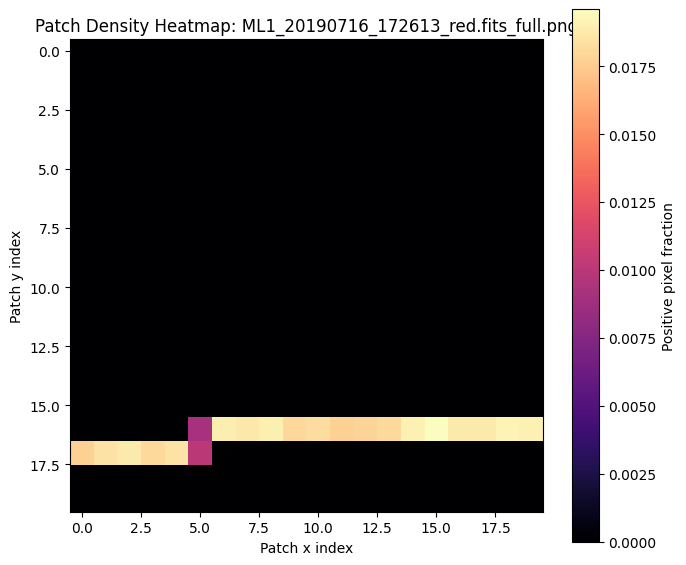

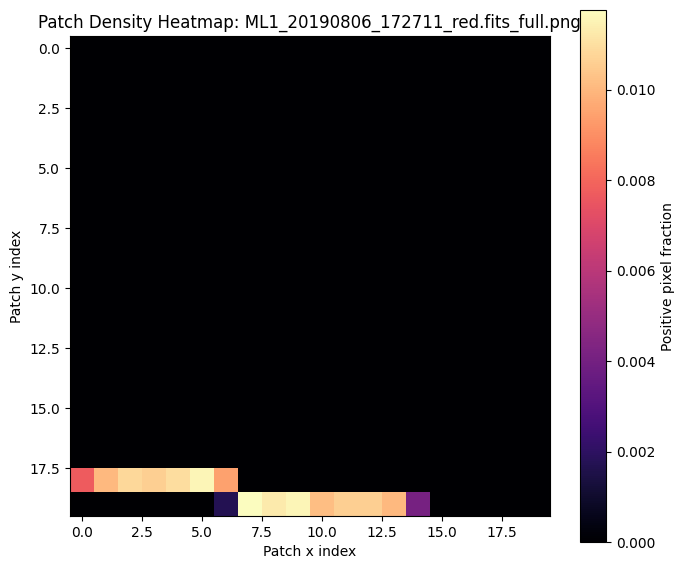

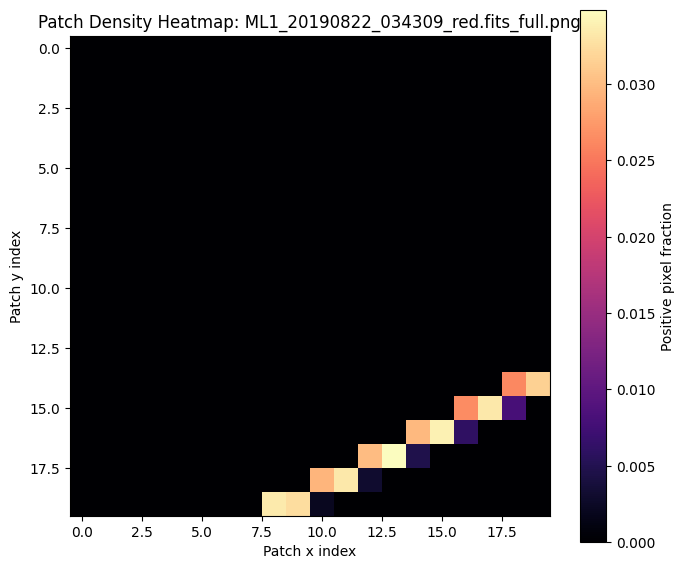

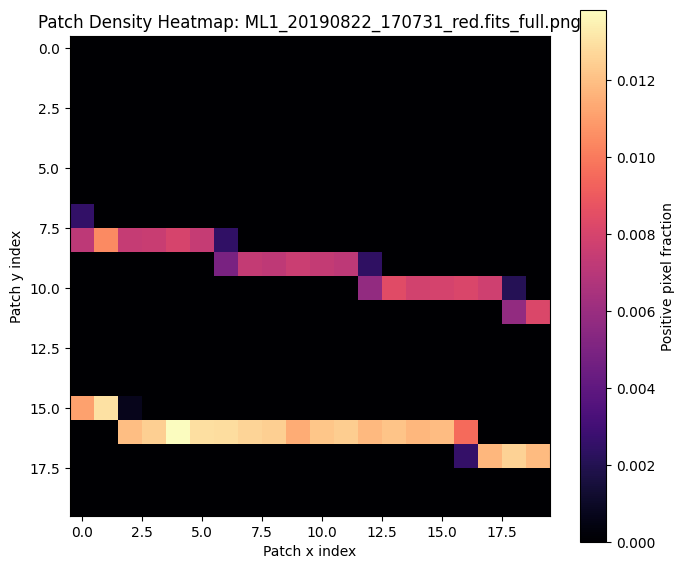

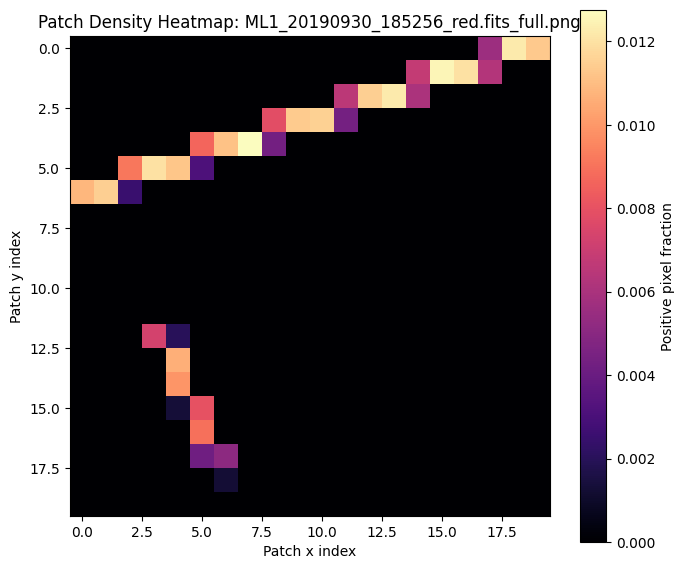

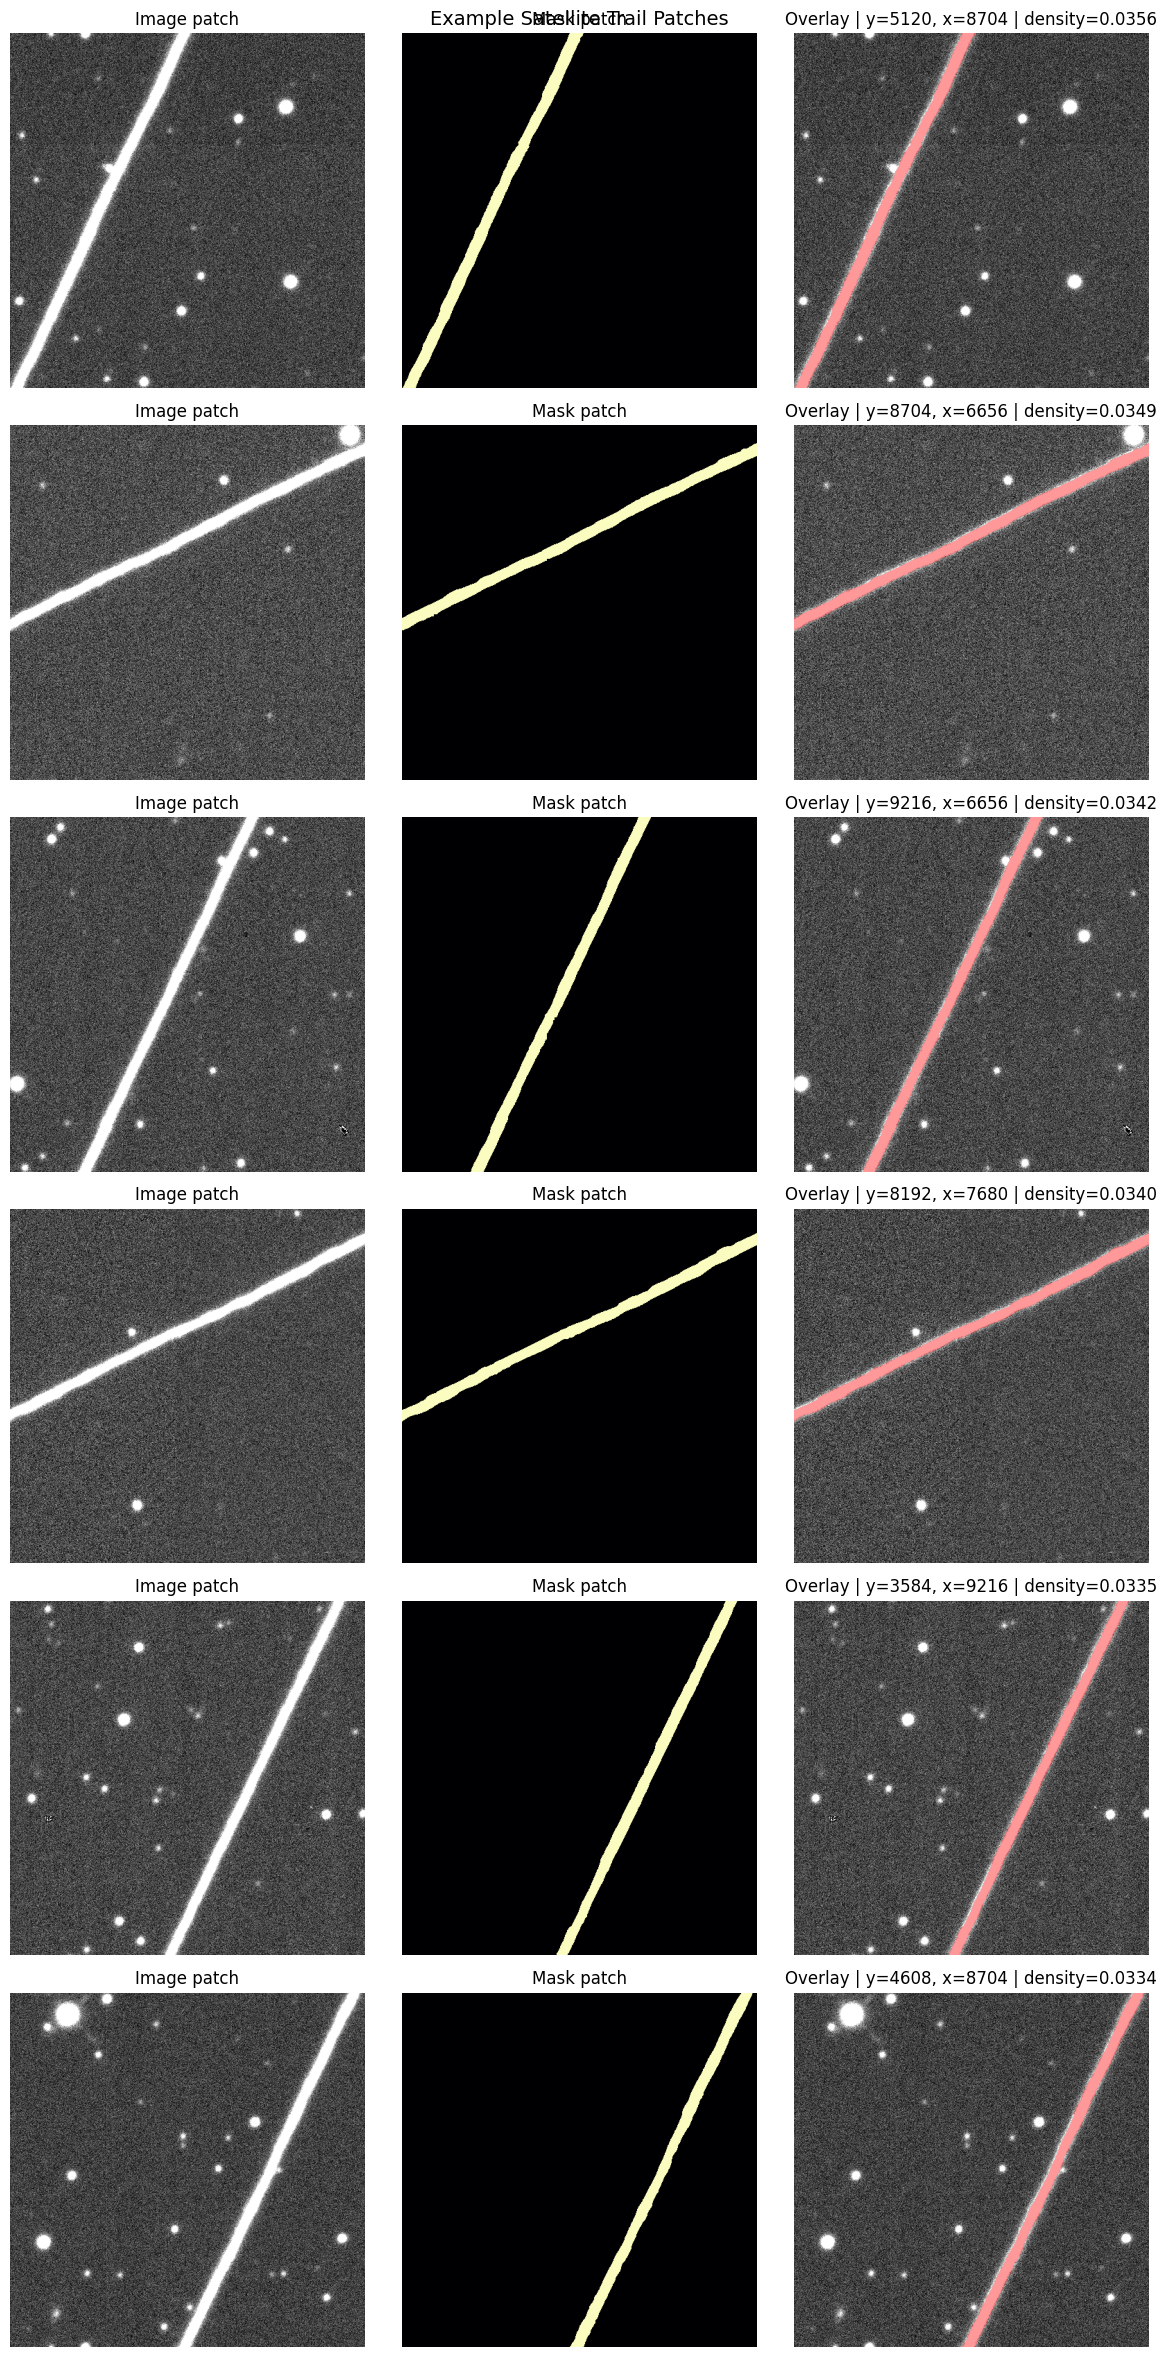

{'random_pairs': PosixPath('results/figures/eda_random_image_mask_pairs.png'),
 'overlays': PosixPath('results/figures/eda_random_mask_overlays.png'),
 'image_level_summary': PosixPath('results/figures/eda_image_level_summary.png'),
 'density_distribution': PosixPath('results/figures/eda_patch_density_distribution.png'),
 'heatmaps': [PosixPath('results/figures/eda_patch_density_heatmap_ML1_20170902_022840_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_002210_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_003240_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_014550_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181227_184754_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181231_193445_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181231_194444_red_fits_full.

In [5]:
figure_paths["image_level_summary"] = plot_image_level_summary(
    image_df=image_df,
    patch_df=patch_df,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["density_distribution"] = plot_patch_density_distribution(
    patch_df=patch_df,
    output_dir=figure_dir,
    logger=logger,
)

heatmap_paths = []
for image_name in patch_df["image_name"].unique():
    heatmap_paths.append(
        plot_patch_density_heatmap(
            patch_df=patch_df,
            image_name=image_name,
            output_dir=figure_dir,
            logger=logger,
        )
    )

figure_paths["heatmaps"] = heatmap_paths
figure_paths["trail_patches"] = plot_example_satellite_trail_patches(
    patch_df=patch_df,
    sample_count=6,
    sort_by_density=True,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths

## Metadata catalogue summary

In [6]:
display(pd.DataFrame([catalog.get_metadata_summary()]))
display(catalog.get_missing_value_counts().to_frame(name="missing_values"))
display(catalog.get_numeric_summary())
display(catalog.get_satellite_frequency(top_n=15).to_frame(name="count"))
display(catalog.get_coordinate_dataframe().head(10))
catalog.get_ra_dec_ranges()

,rows,unique_satellites,labelled_rows,missing_satellite_names
0,9107,727,7365,1742


,missing_values
Length,0
Start_RA,0
End_RA,0
Start_DEC,0
End_DEC,0
Satellite_Name,1742


,count,mean,std,min,25%,50%,75%,max
Length,9107.0,1578.360161,36.475200,1440.001389,1564.013587,1589.075517,1602.007803,1639.856091
Start_RA,9107.0,-84.950934,115.812631,-179.799002,-174.730951,-158.413800,-13.257662,179.760714
End_RA,9107.0,-84.845011,115.794318,-179.820016,-174.541890,-158.562887,-13.009536,179.511657
Start_DEC,9107.0,4.479468,5.389840,-14.639185,4.737104,5.288301,5.424328,23.805641
End_DEC,9107.0,4.495492,5.387840,-14.637271,4.760052,5.289370,5.428857,23.842867


,count
Satellite_Name,
EXPRESS AM-44,118
EXPRESS AM-8,116
WGS 9 (USA 275),107
TELSTAR 12V,105
EUTE 8 WEST B,98
EUTE 5W B,87
MUOS 3,81
LUCH (OLYMP),81
ABS 3A,75


,Satellite_Name,Start_RA,End_RA,Start_DEC,End_DEC,Length
0,EUTE KONNECT,53.041755,53.293008,5.161228,5.162105,1603.011229
1,RADUGA 13,-145.454891,-145.702932,-8.377361,-8.349888,1580.387611
2,HELLAS-SAT 3,-92.709252,-92.455671,5.175605,5.175372,1617.001237
3,ARABSAT 1DR (TELSTAR 3A),153.915035,153.685850,11.409914,11.474425,1495.448093
4,EUTE 2-F2,-27.164865,-26.926716,-6.826902,-6.780034,1549.515085
5,ECHOSTAR 4,-155.784092,-156.025323,7.594085,7.640930,1561.695553
6,RADUGA 1-7,135.081540,134.824851,18.831438,18.849860,1564.233039
7,EUTE 7B (EUTE 3D),165.648527,165.899215,5.354097,5.353666,1593.001255
8,YNET 5B,-174.838254,-174.587095,5.840280,5.839289,1598.005006
9,AL YAH 3,63.563962,63.812343,4.975975,4.976988,1579.007916


{'ra': (-179.82001571554076, 179.76071448252685),
 'dec': (-14.639184524940848, 23.842866806088107)}

## Metadata catalogue visualisations

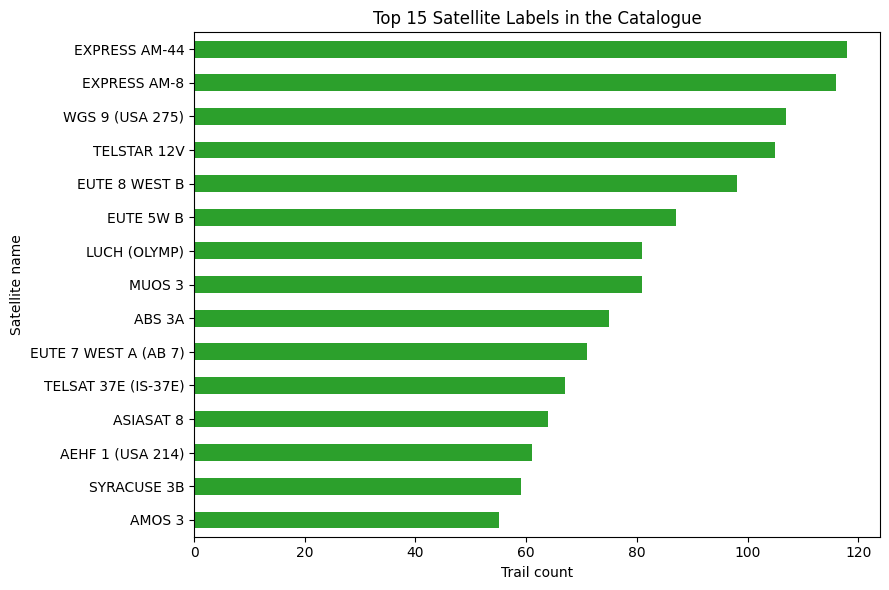

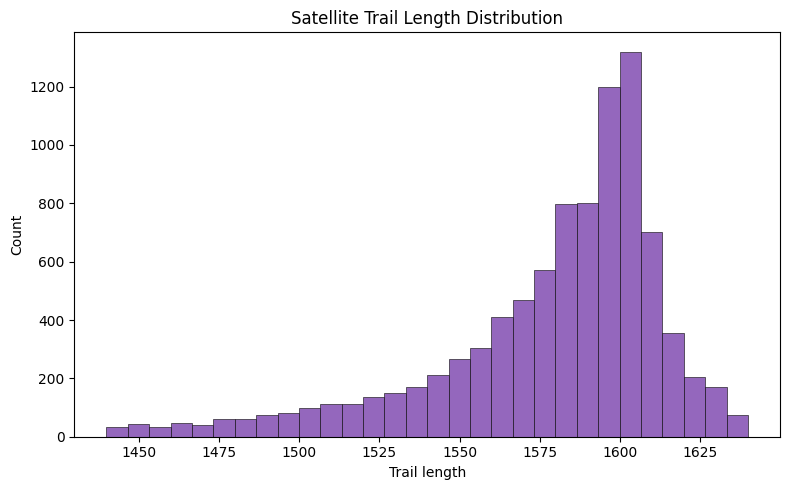

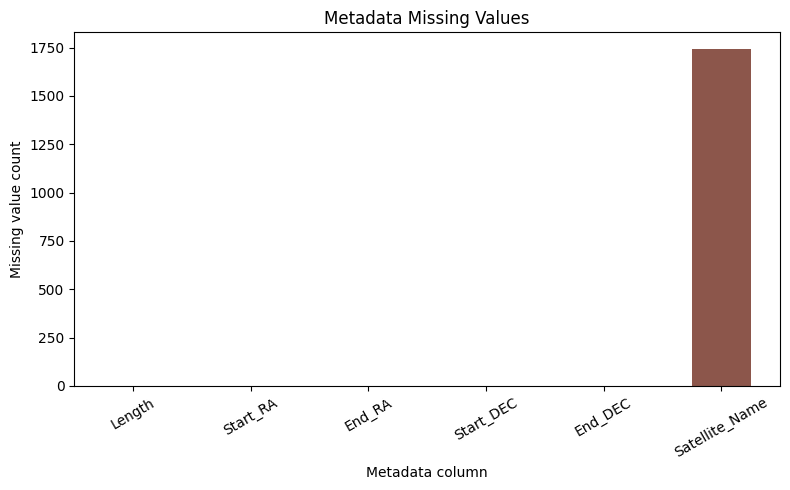

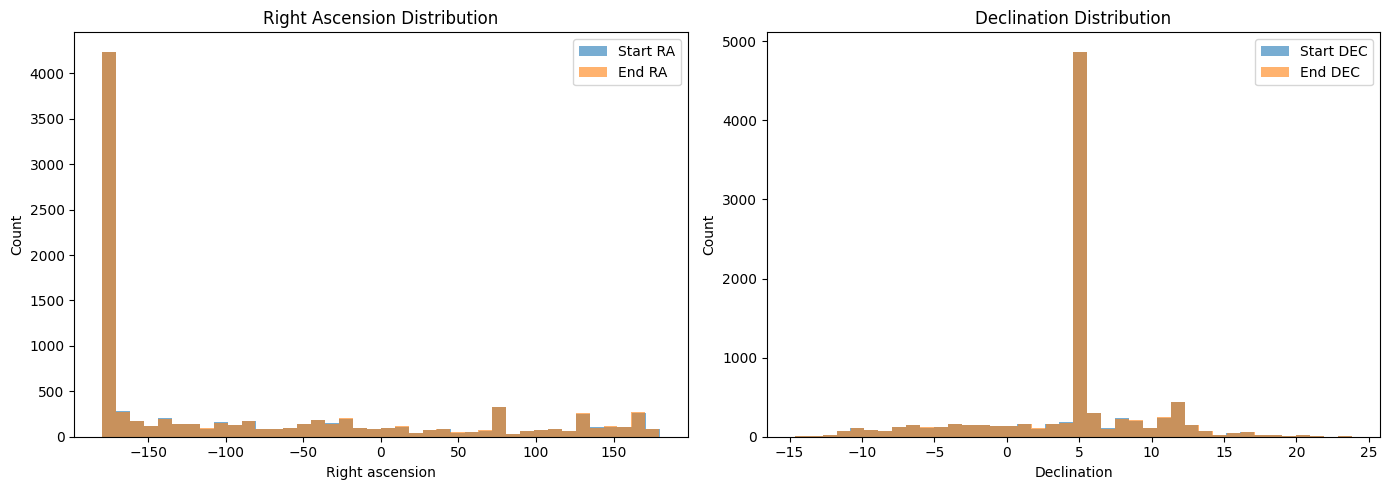

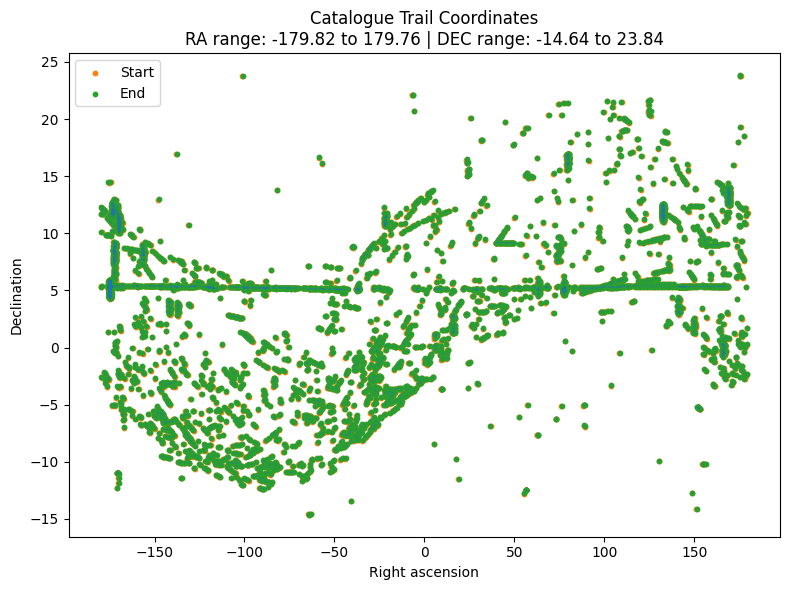

{'random_pairs': PosixPath('results/figures/eda_random_image_mask_pairs.png'),
 'overlays': PosixPath('results/figures/eda_random_mask_overlays.png'),
 'image_level_summary': PosixPath('results/figures/eda_image_level_summary.png'),
 'density_distribution': PosixPath('results/figures/eda_patch_density_distribution.png'),
 'heatmaps': [PosixPath('results/figures/eda_patch_density_heatmap_ML1_20170902_022840_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_002210_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_003240_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20171023_014550_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181227_184754_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181231_193445_red_fits_full.png'),
  PosixPath('results/figures/eda_patch_density_heatmap_ML1_20181231_194444_red_fits_full.

In [7]:
figure_paths["satellite_frequency"] = plot_satellite_name_frequency(
    catalog=catalog,
    top_n=15,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["trail_length_distribution"] = plot_trail_length_distribution(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["metadata_missing_values"] = plot_metadata_missing_values(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["ra_dec_distributions"] = plot_ra_dec_distributions(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths["ra_dec_ranges"] = plot_ra_dec_ranges(
    catalog=catalog,
    output_dir=figure_dir,
    logger=logger,
)
figure_paths